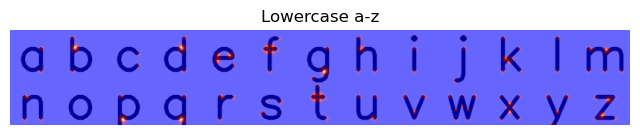

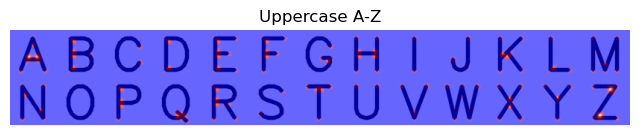

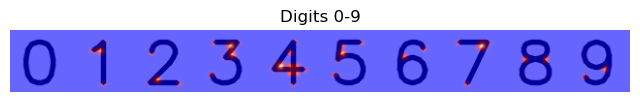

In [135]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import maximum_filter
from matplotlib.colors import LinearSegmentedColormap

heatmap_cmap = LinearSegmentedColormap.from_list('blue_red_white', ['blue', 'red', 'white'], N=256)

def create_char_grid(chars, cell_size=64, num_per_row=None, font_scale=2, thickness=4):
    if num_per_row is None:
        num_per_row = len(chars)
    rows = (len(chars) + num_per_row - 1) // num_per_row
    cols = min(len(chars), num_per_row)
    img_h = rows * cell_size
    img_w = cols * cell_size
    img = np.ones((img_h, img_w), dtype=np.uint8) * 255
    font = cv2.FONT_HERSHEY_SIMPLEX
    for idx, ch in enumerate(chars):
        r, c = divmod(idx, num_per_row)
        x0, y0 = c * cell_size, r * cell_size
        ts = cv2.getTextSize(ch, font, font_scale, thickness)[0]
        x = x0 + (cell_size - ts[0]) // 2
        y = y0 + (cell_size + ts[1]) // 2
        cv2.putText(img, ch, (x, y), font, font_scale, 0, thickness, cv2.LINE_AA)
    return img

def shi_tomasi_overlay(gray, sigma_scale=2, quality_level=0.01):
    gray_f = np.float32(gray)
    eig = cv2.cornerMinEigenVal(gray_f, blockSize=2, ksize=3)
    eig_n = cv2.normalize(eig, None, 0, 1, cv2.NORM_MINMAX)
    peaks = (eig_n == maximum_filter(eig_n, size=3)) & (eig_n > quality_level)
    pts = np.argwhere(peaks)
    confs = eig_n[peaks]
    h, w = gray.shape
    overlay = np.zeros((h, w), float)
    for (r, c), conf in zip(pts, confs):
        sigma = 1 + sigma_scale * conf
        R = int(3 * sigma)
        r0, r1 = max(r-R,0), min(r+R+1,h)
        c0, c1 = max(c-R,0), min(c+R+1,w)
        ys = np.arange(r0, r1)[:,None]
        xs = np.arange(c0, c1)[None,:]
        overlay[r0:r1, c0:c1] += conf * np.exp(-((ys-r)**2 + (xs-c)**2)/(2*sigma*sigma))
    if overlay.max()>0:
        overlay /= overlay.max()
    base = cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB)
    heat = (heatmap_cmap(overlay)[:,:,:3]*255).astype(np.uint8)
    return cv2.addWeighted(heat, 0.6, base, 0.4, 0)

sets = {
    "Lowercase a-z": [chr(i) for i in range(ord('a'), ord('z')+1)],
    "Uppercase A-Z": [chr(i) for i in range(ord('A'), ord('Z')+1)],
    "Digits 0-9": [chr(i) for i in range(ord('0'), ord('9')+1)]
}

for title, chars in sets.items():
    grid = create_char_grid(chars, cell_size=64, num_per_row=13 if len(chars)>10 else len(chars))
    ov = shi_tomasi_overlay(grid, sigma_scale=2, quality_level=0.01)
    plt.figure(figsize=(8,6))
    plt.title(title)
    plt.imshow(ov)
    plt.axis('off')

plt.show()


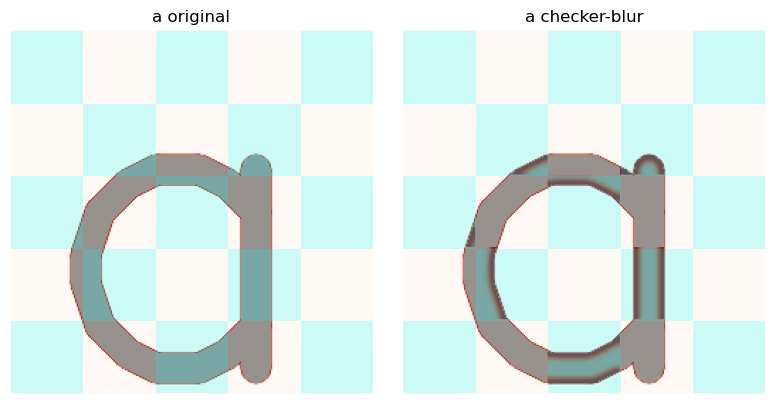

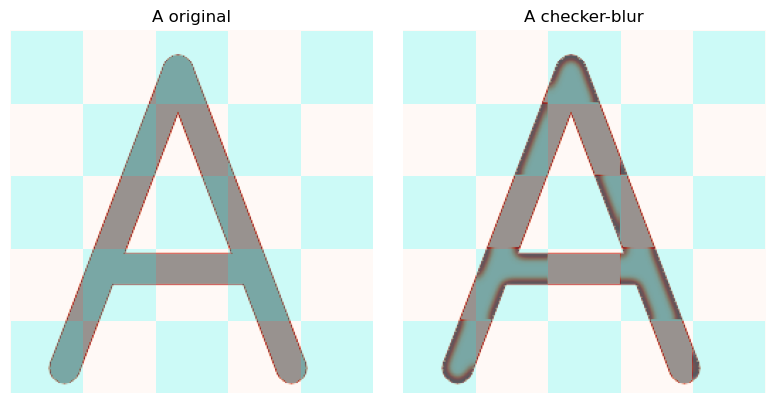

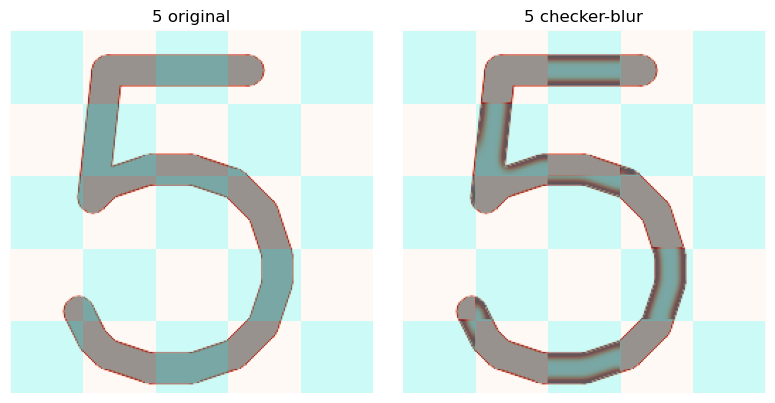

In [4]:
#!/usr/bin/env python3
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# blur_score
def blur_score(img):
    return np.clip(1 - 4*(img - 0.5)**2, 0, 1)

# render single char
def render_char(ch, size=256, font_scale=10, thickness=20):
    img = np.ones((size, size), np.uint8)*255
    font = cv2.FONT_HERSHEY_SIMPLEX
    ts = cv2.getTextSize(ch, font, font_scale, thickness)[0]
    x = (size - ts[0])//2
    y = (size + ts[1])//2
    cv2.putText(img, ch, (x,y), font, font_scale, 0, thickness, cv2.LINE_AA)
    return img

# checkerboard blur only on letter strokes
def blur_letter_checker(img, grid=5, ksize=(21,21)):
    h, w = img.shape
    bh, bw = h//grid, w//grid
    out = img.copy().astype(np.float32)/255
    binary = (img==0)  # mask of letter strokes
    for i in range(grid):
        for j in range(grid):
            if (i+j)%2==0:
                y0,y1 = i*bh, h if i==grid-1 else (i+1)*bh
                x0,x1 = j*bw, w if j==grid-1 else (j+1)*bw
                patch_mask = binary[y0:y1, x0:x1]
                if not patch_mask.any(): 
                    continue
                # blur only stroke pixels: we blur whole patch then mix
                patch = out[y0:y1, x0:x1]
                blurred = cv2.GaussianBlur(patch, ksize, 0)
                patch[patch_mask] = blurred[patch_mask]
                out[y0:y1, x0:x1] = patch
    return (out*255).astype(np.uint8)

# plotting helper
def show_char(ch):
    orig = render_char(ch)
    # blur over checker letter only
    chk = blur_letter_checker(orig)
    # compute masks
    m1 = blur_score(orig.astype(np.float32)/255)
    m2 = blur_score(chk.astype(np.float32)/255)
    # plot
    fig, axes = plt.subplots(1,2,figsize=(8,4))
    for ax, im, mask, title in [
        (axes[0], orig, m1, f"{ch} original"),
        (axes[1], chk, m2, f"{ch} checker-blur")
    ]:
        ax.imshow(im, cmap='gray', vmin=0, vmax=255)
        ax.imshow(mask, cmap='Reds', alpha=0.6, vmin=0, vmax=1)
        # draw checker rectangles on letter region
        h,w = im.shape
        gh = gw = 5
        bh, bw = h/gh, w/gw
        for i in range(gh):
            for j in range(gw):
                if (i+j)%2==0:
                    rect = Rectangle((j*bw,i*bh),bw,bh,
                                     facecolor='cyan', alpha=0.2, edgecolor=None)
                    ax.add_patch(rect)
        ax.set_title(title); ax.axis('off')
    plt.tight_layout()
    plt.show()

for ch in ['a','A','5']:
    show_char(ch)


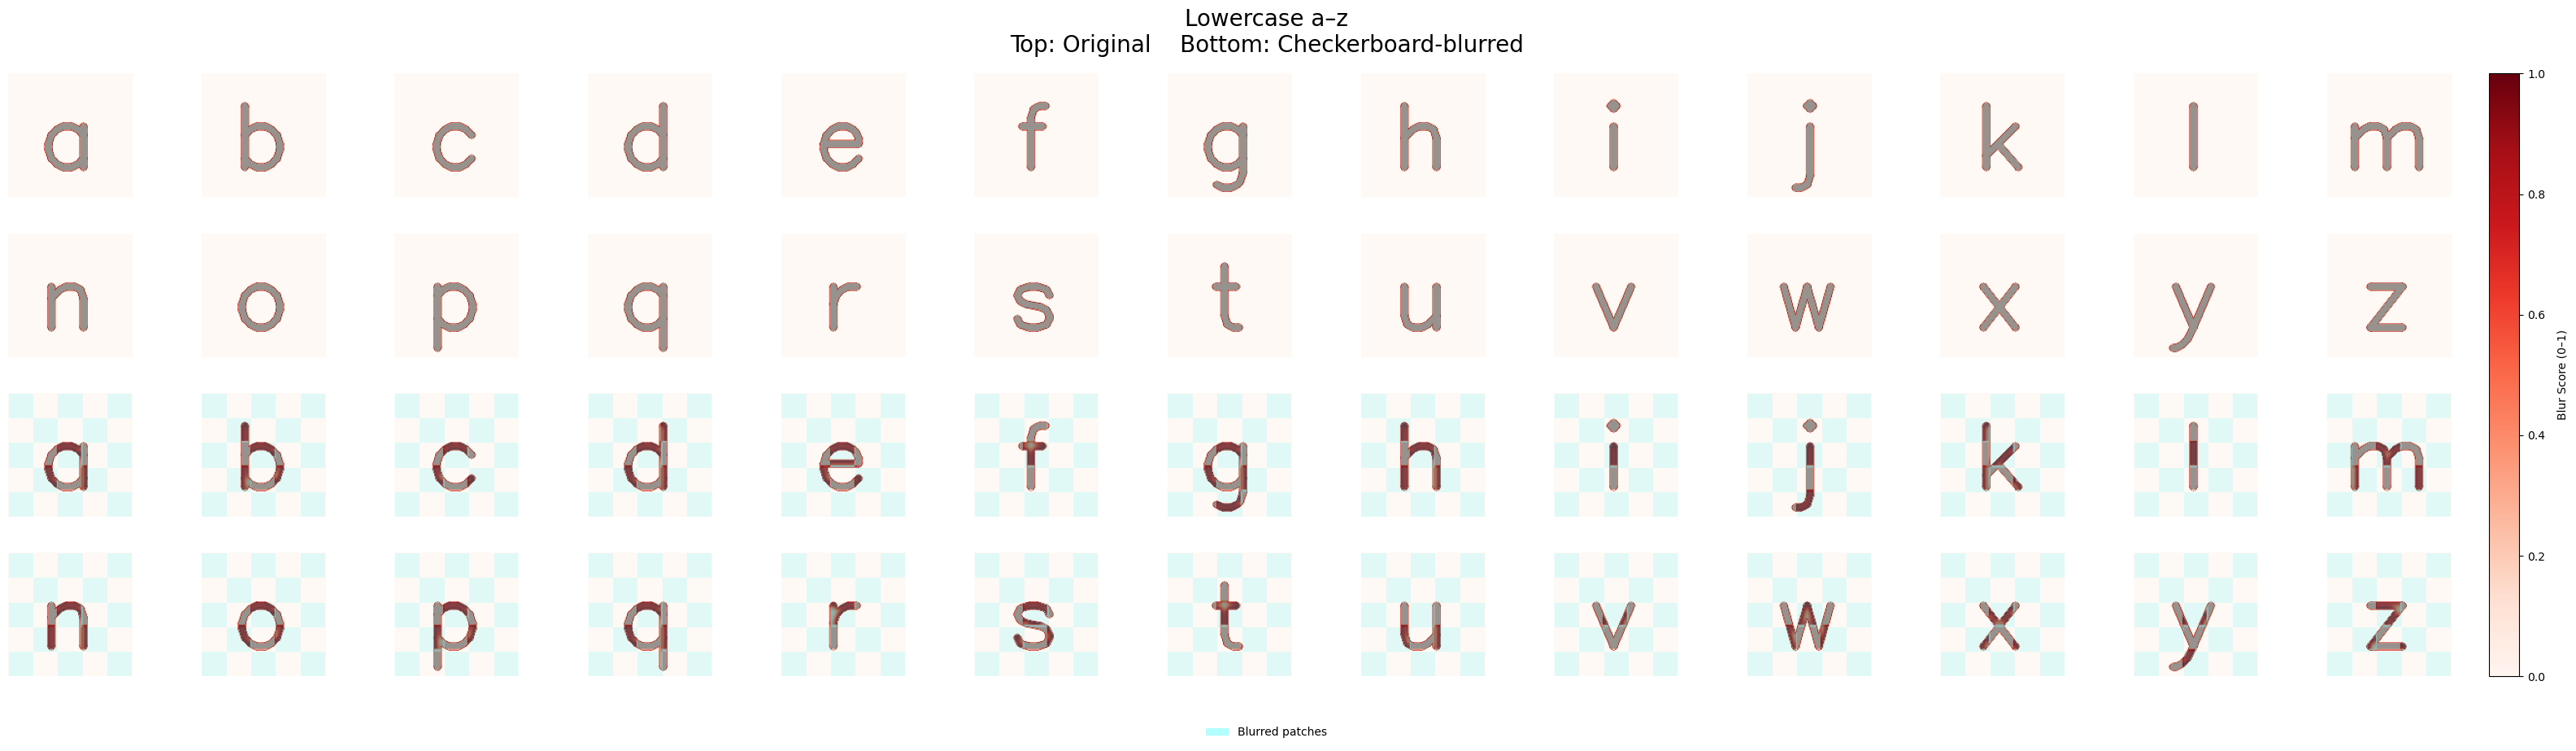

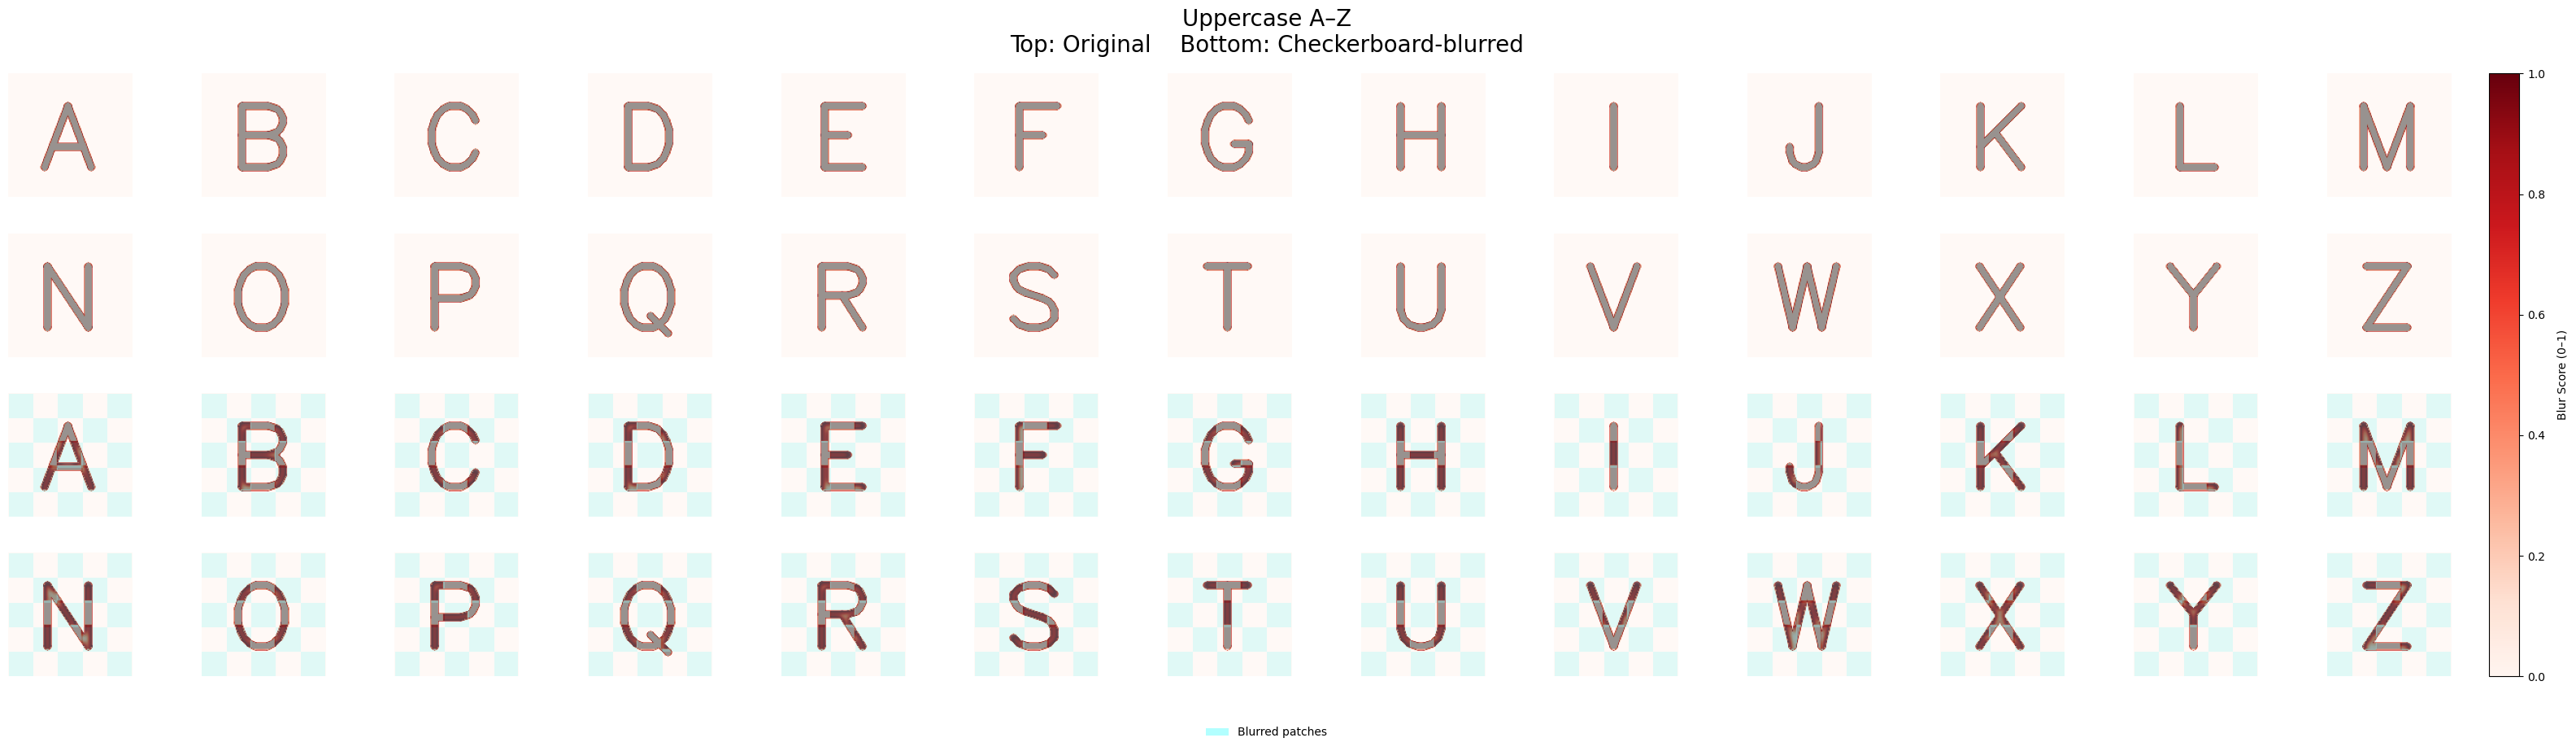

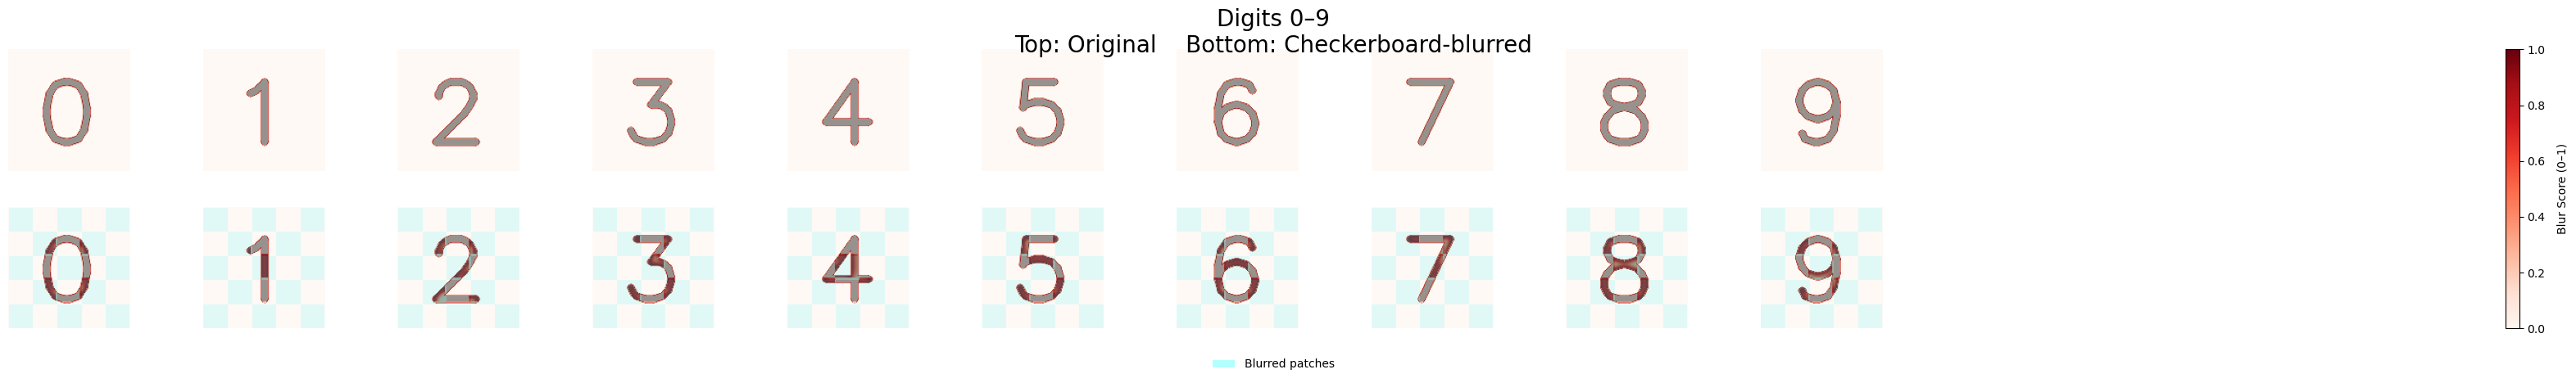

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.cm import ScalarMappable

# blur_score function (maps pixel intensity to blur score)
def blur_score(img):
    return np.clip(1 - 4 * (img - 0.5)**2, 0, 1)

# render single char
def render_char(ch, size=128, font_scale=3, thickness=6):
    img = np.ones((size, size), dtype=np.uint8) * 255
    font = cv2.FONT_HERSHEY_SIMPLEX
    ts = cv2.getTextSize(ch, font, font_scale, thickness)[0]
    x = (size - ts[0]) // 2
    y = (size + ts[1]) // 2
    cv2.putText(img, ch, (x, y), font, font_scale, 0, thickness, cv2.LINE_AA)
    return img

# checkerboard blur only on letter strokes
def blur_letter_checker(img, grid=5, ksize=(21, 21)):
    h, w = img.shape
    bh, bw = h // grid, w // grid
    out = img.copy().astype(np.float32) / 255
    mask_stroke = (img == 0)
    for i in range(grid):
        for j in range(grid):
            if (i + j) % 2 == 0:
                y0, y1 = i * bh, (i + 1) * bh if i < grid - 1 else h
                x0, x1 = j * bw, (j + 1) * bw if j < grid - 1 else w
                region = mask_stroke[y0:y1, x0:x1]
                if region.any():
                    patch = out[y0:y1, x0:x1]
                    blurred = cv2.GaussianBlur(patch, ksize, 0)
                    patch[region] = blurred[region]
                    out[y0:y1, x0:x1] = patch
    return (out * 255).astype(np.uint8)

# plotting function with checkerboard blur + heatmap
def plot_set(chars, title, grid=5):
    cols = 13
    rows = (len(chars) + cols - 1) // cols
    total_rows = rows * 2

    fig, axes = plt.subplots(total_rows, cols,
                             figsize=(cols * 2.5, total_rows * 2.5))
    fig.subplots_adjust(top=0.9, bottom=0.1, hspace=0.4, wspace=0.2)
    plt.tight_layout(rect=[0, 0.1, 1, 0.9])

    # prepare colorbar
    sm = ScalarMappable(cmap='Reds', norm=plt.Normalize(0, 1))
    sm.set_array([])

    for idx, ch in enumerate(chars):
        r = idx // cols
        c = idx % cols

        # original image + heatmap
        ax0 = axes[r, c]
        img0 = render_char(ch)
        norm0 = img0.astype(np.float32) / 255
        mask0 = blur_score(norm0)
        ax0.imshow(img0, cmap='gray', vmin=0, vmax=255, zorder=0)
        ax0.imshow(mask0, cmap='Reds', alpha=0.6, vmin=0, vmax=1, zorder=2)
        ax0.axis('off')

        # checkerboard-blurred image
        ax1 = axes[r + rows, c]
        img1 = blur_letter_checker(img0, grid=grid)
        norm1 = img1.astype(np.float32) / 255
        mask1 = blur_score(norm1)
        ax1.imshow(img1, cmap='gray', vmin=0, vmax=255, zorder=0)

        # draw checkerboard overlay
        h, w = img1.shape
        bh, bw = h / grid, w / grid
        for i in range(grid):
            for j in range(grid):
                if (i + j) % 2 == 0:
                    rect = Rectangle((j * bw, i * bh), bw, bh,
                                     facecolor='cyan', alpha=0.3, edgecolor=None, zorder=1)
                    ax1.add_patch(rect)

        # overlay heatmap of blur detection
        ax1.imshow(mask1, cmap='Reds', alpha=0.6, vmin=0, vmax=1, zorder=2)
        ax1.axis('off')

    # hide unused axes
    for k in range(len(chars), cols * total_rows):
        axes.flat[k].axis('off')

    # colorbar closer without overlap
    cbar = fig.colorbar(sm, ax=axes, fraction=0.03, pad=0.015, orientation='vertical')
    cbar.set_label('Blur Score (0–1)', labelpad=10)

    # legend for checkerboard
    legend_patch = Rectangle((0, 0), 1, 1, facecolor='cyan', alpha=0.3)
    fig.legend([legend_patch], ['Blurred patches'],
               loc='lower center', ncol=1, frameon=False,
               bbox_to_anchor=(0.5, 0.05))

    # main title formatting
    fig.suptitle(f"{title}\nTop: Original    Bottom: Checkerboard-blurred",
                 fontsize=20, y=0.96)
    plt.show()

# sets
def main():
    lowercase = [chr(i) for i in range(ord('a'), ord('z') + 1)]
    uppercase = [chr(i) for i in range(ord('A'), ord('Z') + 1)]
    digits = [chr(i) for i in range(ord('0'), ord('9') + 1)]

    display_sets = [
        (lowercase, "Lowercase a–z"),
        (uppercase, "Uppercase A–Z"),
        (digits, "Digits 0–9")
    ]
    for chars, title in display_sets:
        plot_set(chars, title)

if __name__ == '__main__':
    main()



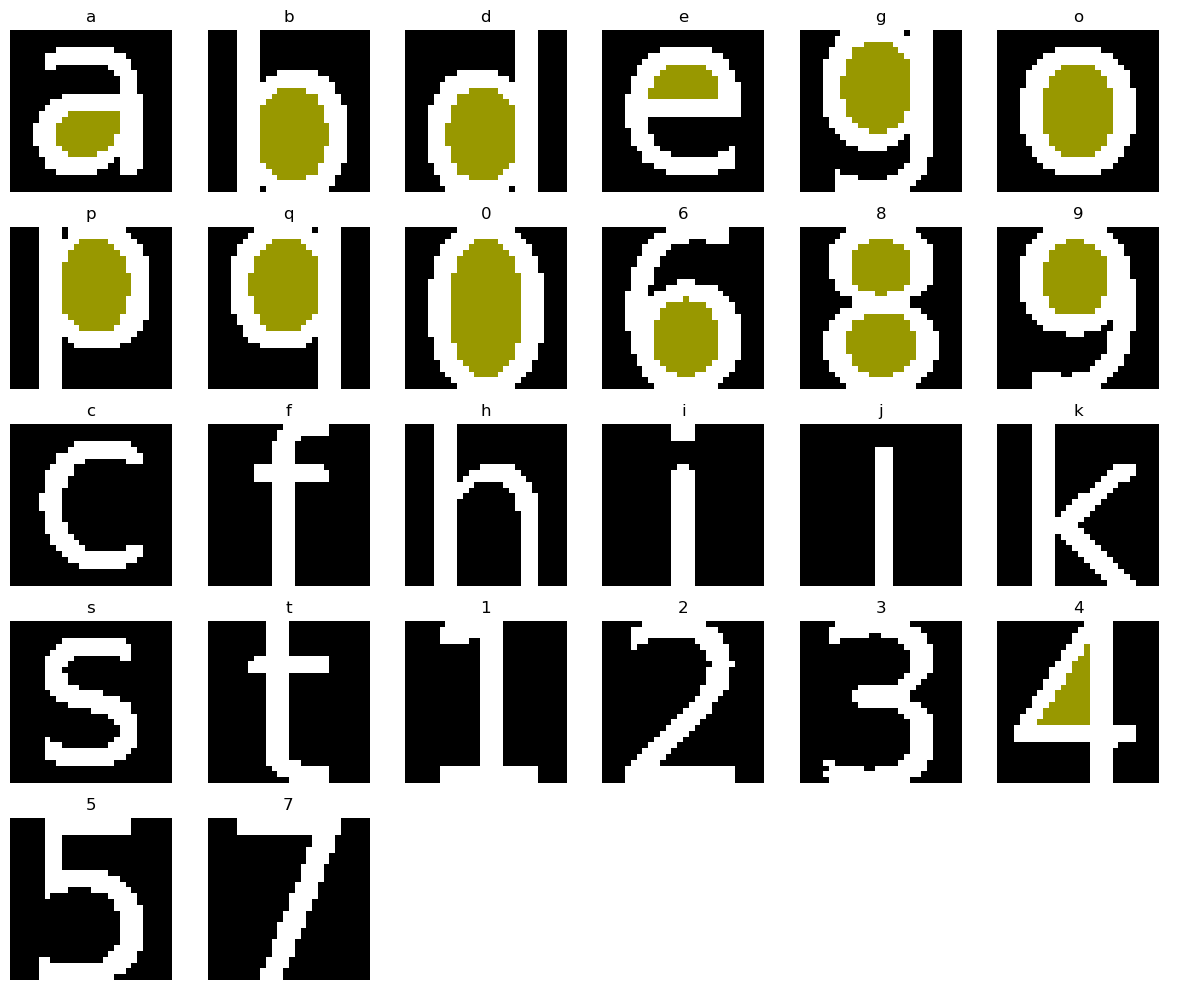

In [79]:
import numpy as np
import cv2
from PIL import Image, ImageDraw, ImageFont
from skimage.morphology import closing, square
from scipy.ndimage import binary_fill_holes
def mask_hierarchy(bin_img: np.ndarray) -> np.ndarray:
    """Rileva i fori tramite hierarchy dei contorni."""
    contours, hierarchy = cv2.findContours(bin_img, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(bin_img, dtype=np.uint8)
    if hierarchy is None:
        return mask.astype(bool)
    for i, h in enumerate(hierarchy[0]):
        if h[3] != -1:
            cv2.drawContours(mask, contours, i, 255, thickness=-1)
    return mask.astype(bool)
def mask_hierarchy_clean(bin_img: np.ndarray) -> np.ndarray:
    """Estende hierarchy rimuovendo pixel su carattere e bordo immagine."""
    hole = mask_hierarchy(bin_img)
    # rimuovi pixel su carattere (255)
    hole = hole & (bin_img == 0)
    # rimuovi pixel bordo
    hole[0, :] = False
    hole[-1, :] = False
    hole[:, 0] = False
    hole[:, -1] = False
    return hole
# ------------------------------------------------------------------ #
# Demo: gerarchia pulita su lettere bianche su sfondo nero
# ------------------------------------------------------------------ #
if __name__ == '__main__':
    letters = list('abdegopq0689cfhijkst123457')
    try:
        font = ImageFont.truetype('DejaVuSans.ttf', 180)
    except IOError:
        font = ImageFont.load_default()
    ncols = 6
    nrows = (len(letters) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2, nrows*2))
    axes = axes.flatten()
    for idx, ch in enumerate(letters):
        # canvas nero, carattere bianco
        canvas = Image.new('L', (128,128), 0)
        draw = ImageDraw.Draw(canvas)
        bbox = draw.textbbox((0,0), ch, font=font)
        w, h = bbox[2]-bbox[0], bbox[3]-bbox[1]
        draw.text(((128-w)/2 - bbox[0], (128-h)/2 - bbox[1]), ch, font=font, fill=255)
        img28 = canvas.resize((28,28), Image.LANCZOS)
        im8 = np.asarray(img28).astype(np.uint8)
        # binarizza (0 sfondo, 255 carattere)
        _, bin_char = cv2.threshold(im8, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
        # calcola mask hierarchy-clean
        mask = mask_hierarchy_clean(bin_char)
        # visualizza
        ax = axes[idx]
        ax.imshow(bin_char, cmap='gray')
        overlay = np.zeros((28,28,4), dtype=float)
        overlay[mask, :] = [1.0, 1.0, 0.0, 0.6]  # giallo
        ax.imshow(overlay)
        ax.set_title(ch)
        ax.axis('off')
    for ax in axes[len(letters):]:
        ax.axis('off')
    plt.tight_layout()
    plt.show()


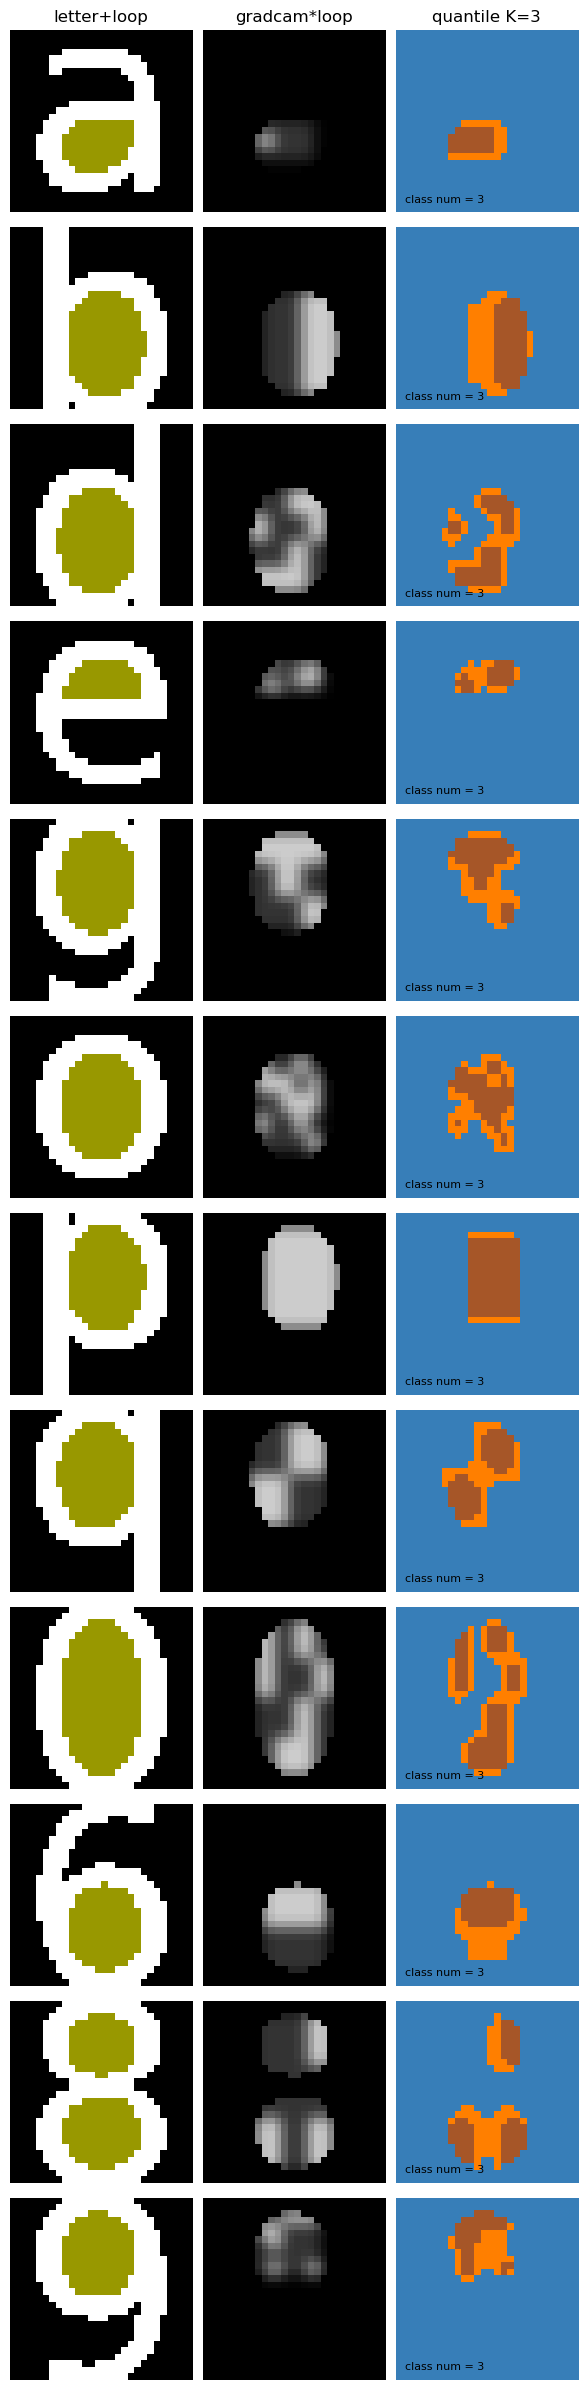

In [80]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
from scipy.ndimage import binary_fill_holes
def mask_hierarchy(bin_img: np.ndarray) -> np.ndarray:
    """Rileva i fori tramite hierarchy dei contorni."""
    contours, hierarchy = cv2.findContours(bin_img, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(bin_img, dtype=np.uint8)
    if hierarchy is None:
        return mask.astype(bool)
    for i, h in enumerate(hierarchy[0]):
        if h[3] != -1:
            cv2.drawContours(mask, contours, i, 255, thickness=-1)
    return mask.astype(bool)
def mask_hierarchy_clean(bin_img: np.ndarray) -> np.ndarray:
    """Estende mask_hierarchy rimuovendo pixel su carattere e bordo immagine."""
    hole = mask_hierarchy(bin_img)
    # rimuovi pixel su carattere (255)
    hole = hole & (bin_img == 0)
    # rimuovi pixel bordo
    hole[0, :] = False
    hole[-1, :] = False
    hole[:, 0] = False
    hole[:, -1] = False
    return hole
# ------------------------------------------------------------------ #
# Synthetic Grad-CAM e clustering
# ------------------------------------------------------------------ #
def synthetic_gradcam_checker(loop_mask):
    h, w = loop_mask.shape
    ys, xs = np.where(loop_mask)
    if len(ys) == 0:
        return np.zeros_like(loop_mask, float)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    sh, sw = y1 - y0 + 1, x1 - x0 + 1
    n_cells = random.randint(2,5)
    ch, cw = max(1, sh//n_cells), max(1, sw//n_cells)
    pattern = np.zeros((sh, sw), float)
    for i in range(n_cells):
        for j in range(n_cells):
            val = random.choice([0.2, 0.8])
            pattern[i*ch:(i+1)*ch, j*cw:(j+1)*cw] = val
    grad = np.zeros((h, w), float)
    grad[y0:y1+1, x0:x1+1] = pattern
    return cv2.GaussianBlur(grad, (5,5), 0)
def cluster_quantile(grad, mask, K=3):
    vals = grad[mask]
    thr = [np.percentile(vals, 100*i/K) for i in range(1, K)]
    lbl = np.zeros_like(grad, int)
    seg = np.digitize(grad[mask], bins=thr)
    lbl[mask] = seg
    return lbl
# ------------------------------------------------------------------ #
# Palette colorblind-friendly
# ------------------------------------------------------------------ #
cb_colors = [
    (55/255, 126/255, 184/255),
    (255/255, 127/255,   0/255),
    (166/255,  86/255,  40/255)
]

import random
letters = ['a','b','d','e','g','o','p','q','0','6','8','9']
methods = [
    ('quantile K=3', lambda g, m: cluster_quantile(g, m, K=3))
]

nrows = len(letters)
ncols = 3
fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*2, nrows*2))
# Carica font
try:
    font = ImageFont.truetype('DejaVuSans.ttf', 180)
except:
    font = ImageFont.load_default()

for i, ch in enumerate(letters):
    # Generazione lettera invertita: sfondo nero, carattere bianco
    canvas = Image.new('L', (128,128), 0)
    draw = ImageDraw.Draw(canvas)
    bb = draw.textbbox((0,0), ch, font=font)
    w, h = bb[2]-bb[0], bb[3]-bb[1]
    draw.text(((128-w)/2 - bb[0], (128-h)/2 - bb[1]), ch, font=font, fill=255)
    img28 = canvas.resize((28,28), Image.Resampling.LANCZOS)
    im8 = np.array(img28).astype(np.uint8)
    # binarizza: 0 sfondo, 255 carattere
    _, bin_char = cv2.threshold(im8, 0, 255, cv2.THRESH_BINARY | cv2.THRESH_OTSU)
    letter = (bin_char == 255)
    # calcola loop con hierarchy-clean
    loop = mask_hierarchy_clean(bin_char)
    # gradcam sintetico
    grad = synthetic_gradcam_checker(loop)
    # Col 0: letter+loop
    ax = axes[i, 0]
    ax.imshow(letter, cmap='gray')
    overlay = np.zeros((28,28,4), float)
    overlay[loop] = [1,1,0,0.6]
    ax.imshow(overlay)
    ax.axis('off')
    if i == 0: ax.set_title('letter+loop')
    # Col 1: gradcam*loop
    ax = axes[i, 1]
    mgrad = grad * loop
    ax.imshow(mgrad, cmap='gray', vmin=0, vmax=1)
    ax.axis('off')
    if i == 0: ax.set_title('gradcam*loop')
    # Col 2: quantile K=3
    ax = axes[i, 2]
    lbl = methods[0][1](grad, loop)
    imgc = np.ones((28,28,3), float)
    for val in np.unique(lbl):
        mask_val = (lbl == val)
        color = cb_colors[val] if val < len(cb_colors) else (0,0,0)
        imgc[mask_val] = color
    ax.imshow(imgc)
    count = len(np.unique(lbl))
    ax.text(1, 26, f'class num = {count}', fontsize=8, color='black')
    ax.axis('off')
    if i == 0: ax.set_title('quantile K=3')

for ax in axes[len(letters):]:
    ax.axis('off')
plt.tight_layout()
plt.show()


In [ ]:
import os
import re
import random
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import struct
from skimage.morphology import closing, square

# --- ROOT fisso per heatmap files ---
ROOT = Path("/home/magliolo/KAN/ConvolutionalKans/Convolutional-KANs/results")
VARIANTS = ["None"]
MODEL_DIRS = {"Standard_LeNet5": (0, 0), "KaNet5": (5, 3)}
MODEL_NAMES = {"Standard_LeNet5": "LeNet5 No Norm", "KaNet5": "KaNet5 No Norm"}
TYPES = {"featuremap": "FeatureMap", "gradcam": "GradCAM"}
SUFFIX = {"featuremap": "_fmap_up.npy", "gradcam": "_gcam_up.npy"}
TOTAL_EPOCHS = 50
HEATMAP_CMAP = plt.get_cmap('jet')

# Percorso dati idx EMNIST
DATA_DIR = '/home/magliolo/.cache/emnist/gzip/'
TRAIN_PATH = os.path.join(DATA_DIR, 'emnist-byclass-train-images-idx3-ubyte')
TEST_PATH  = os.path.join(DATA_DIR, 'emnist-byclass-test-images-idx3-ubyte')

# --- Funzioni di utilità per EMNIST ---
def read_idx_header(fp: str):
    with open(fp, 'rb') as f:
        _, num, rows, cols = struct.unpack('>IIII', f.read(16))
    return num, rows, cols

train_n, IMG_ROWS, IMG_COLS = read_idx_header(TRAIN_PATH)
test_n, _, _ = read_idx_header(TEST_PATH)

def read_idx_image(fp: str, idx: int) -> np.ndarray:
    with open(fp, 'rb') as f:
        f.seek(16 + idx * IMG_ROWS * IMG_COLS)
        buf = f.read(IMG_ROWS * IMG_COLS)
    return np.frombuffer(buf, dtype=np.uint8).reshape(IMG_ROWS, IMG_COLS)

def get_emnist_image(idx: int) -> np.ndarray:
    if idx < train_n:
        return read_idx_image(TRAIN_PATH, idx)
    else:
        return read_idx_image(TEST_PATH, idx - train_n)

# --- Mask extraction ---
def mask_hierarchy(bin_img: np.ndarray) -> np.ndarray:
    contours, hierarchy = cv2.findContours(bin_img, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(bin_img, dtype=np.uint8)
    if hierarchy is None:
        return mask.astype(bool)
    for i, h in enumerate(hierarchy[0]):
        if h[3] != -1:
            cv2.drawContours(mask, contours, i, 255, thickness=-1)
    return mask.astype(bool)

def mask_hierarchy_clean(bin_img: np.ndarray) -> np.ndarray:
    hole = mask_hierarchy(bin_img)
    hole = hole & (bin_img == 0)
    hole[0, :] = False
    hole[-1, :] = False
    hole[:, 0] = False
    hole[:, -1] = False
    return hole

def convexity_defects_opening_mask(img_gray: np.ndarray,
                                   dilate_iter: int = 1,
                                   dilate_kernel_size: int = 3) -> np.ndarray:
    _, binary = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary = (binary // 255).astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilate_kernel_size, dilate_kernel_size))
    dilated = cv2.dilate(binary, kernel, iterations=dilate_iter)
    contours, _ = cv2.findContours(dilated*255, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.zeros_like(binary, dtype=np.uint8)
    cnt = contours[0]
    hull = cv2.convexHull(cnt, returnPoints=False)
    if hull is None or len(hull) <= 3:
        return np.zeros_like(binary, dtype=np.uint8)
    defects = cv2.convexityDefects(cnt, hull)
    if defects is None:
        return np.zeros_like(binary, dtype=np.uint8)
    mask = np.zeros_like(binary, dtype=np.uint8)
    for i in range(defects.shape[0]):
        s, e, f, _ = defects[i, 0]
        tri = np.array([cnt[s][0], cnt[f][0], cnt[e][0]])
        cv2.fillConvexPoly(mask, tri, 1)
    edges = cv2.Canny(img_gray, 30, 100)
    kernel_edge = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    edges_dilated = cv2.dilate(edges, kernel_edge, iterations=1)
    mask[edges_dilated > 0] = 0
    return mask

# --- Quantile clustering ---
def cluster_quantile(grad: np.ndarray, mask: np.ndarray, K: int = 3) -> np.ndarray:
    lbl = np.zeros_like(grad, dtype=int)
    vals = grad[mask]
    if vals.size == 0:
        return lbl
    thresholds = [np.percentile(vals, 100 * i / K) for i in range(1, K)]
    seg = np.digitize(vals, bins=thresholds)
    lbl[mask] = seg
    return lbl

# --- Collect heatmap files ---
def collect_heatmap_files() -> dict[str, list[Path]]:
    files_by_type = {ht: [] for ht in SUFFIX}
    for variant in VARIANTS:
        for model, (g, s) in MODEL_DIRS.items():
            for htype, suf in SUFFIX.items():
                base = ROOT / f"results_{variant}_SGD_lr0.01_{g}_{s}" / model / TYPES[htype]
                for epoch in range(1, TOTAL_EPOCHS+1):
                    folder = base / f"epoch_{epoch}" / "extracted_random_examples" / "Upsampled"
                    if folder.exists():
                        files_by_type[htype] += list(folder.glob(f"*{suf}"))
    return files_by_type

# --- Main display ---
def show_comparison_and_table(sample_size: int = 3):
    files_by_type = collect_heatmap_files()
    for htype, files in files_by_type.items():
        fm = {m: [fp for fp in files if f"/{m}/" in fp.as_posix()] for m in MODEL_DIRS}
        idxs = {m: {int(re.search(r'idx_(\d+)', fp.stem).group(1)) for fp in fps} for m, fps in fm.items()}
        common = set.intersection(*idxs.values())
        sample_idxs = random.sample(list(common), min(sample_size, len(common)))

        all_titles = [
            'Orig EMNIST', f'{htype} norm', 'Corner', 'Edge',
            f'{htype}×Edge', f'{htype}×Corner', 'Orig RGB',
            'Orig+ORL overlay', 'Original+loop detection',
            'Heat*Loop', 'Segmentation heat*loop', f'{htype}×ORL Mask', 'Orig×Heat',
            'Orig+VCR Mask', 'FeatureMap×VCR Mask', 'GradCAM×VCR Mask'
        ]
        seg_idx = all_titles.index('Segmentation heat*loop')
        n_rows = int(np.ceil(len(all_titles) / 2))

        for idx in sample_idxs:
            fig, axes = plt.subplots(
                n_rows, 4,
                figsize=(32, 8 * n_rows),
                gridspec_kw={'wspace': 0.02, 'hspace': 0.3}
            )

            raw = get_emnist_image(idx)
            img = np.rot90(np.fliplr(raw), k=1)
            img_n = img.astype(np.float32) / 255.0
            _, bin_char = cv2.threshold((img_n*255).astype(np.uint8), 0, 255,
                                        cv2.THRESH_BINARY | cv2.THRESH_OTSU)

            # compute LVCCR on original grayscale for VCR mask
            tau_orig = 0.1
            h_o, w_o = img_n.shape
            lvccr_j_orig = np.zeros(w_o)
            for j in range(w_o):
                col_bin = (img_n[:, j] >= tau_orig).astype(int)
                runs = np.diff(np.where(
                    np.concatenate(([col_bin[0]], col_bin[:-1] != col_bin[1:], [True]))
                )[0])[::2]
                L_j = runs.max() if runs.size > 0 else 0
                lvccr_j_orig[j] = L_j / h_o
            thr_orig = np.percentile(lvccr_j_orig, 90)
            vcr_mask_orig = (lvccr_j_orig >= thr_orig)

            loop_mask = mask_hierarchy_clean(bin_char)
            mask_orl = convexity_defects_opening_mask((img_n*255).astype(np.uint8))
            orig_rgb = np.stack([img_n]*3, axis=-1)
            # create VCR overlay on original
            overlay_vcr_orig = orig_rgb.copy()
            # apply VCR mask on columns
            overlay_vcr_orig[:, vcr_mask_orig, :] = [1, 0, 0]

            overlay_loop = np.stack([bin_char==255]*3, axis=-1).astype(float)
            overlay_loop[loop_mask] = [1, 0, 0]
            overlay_orl = orig_rgb.copy()
            overlay_orl[mask_orl==1] = [1, 0, 0]
            edge_n = np.abs(cv2.Sobel(img_n, cv2.CV_32F, 1, 0, ksize=3))
            edge_n /= edge_n.max() or 1
            corner_n = cv2.cornerMinEigenVal(img_n, 2, 3)
            corner_n /= corner_n.max() or 1

            for t, title in enumerate(all_titles):
                row = t // 2
                pair_idx = t % 2
                for m_idx, model in enumerate(MODEL_DIRS):
                    fp = next(fp for fp in fm[model] if f"idx_{idx}" in fp.stem)
                    heat = np.rot90(np.fliplr(np.load(fp).astype(np.float32)), k=1)
                    heat_n = heat / (heat.max() or 1.0)

                    lbl3 = cluster_quantile(heat_n * loop_mask, loop_mask, 3)
                    colors = [(230/255,25/255,75/255),(60/255,180/255,75/255),(255/255,225/255,25/255)]
                    cluster_img = np.zeros_like(np.stack([heat_n*loop_mask]*3, axis=-1))
                    for val in np.unique(lbl3):
                        if val > 0 and val <= len(colors):
                            cluster_img[lbl3==val] = colors[val-1]

                    heat_orl = heat_n * mask_orl

                    # variants including VCR overlays
                    variants = [
                        img, heat_n, corner_n, edge_n,
                        heat_n*edge_n, heat_n*corner_n, orig_rgb,
                        overlay_orl, overlay_loop, heat_n*loop_mask,
                        cluster_img, heat_orl, img_n*heat_n,
                        overlay_vcr_orig,
                        heat_n * vcr_mask_orig,
                        heat_n * vcr_mask_orig
                    ]
                    img_plot = variants[t]

                    ax = axes[row, pair_idx*2 + m_idx]
                    if t in (6, 7, 8, seg_idx):
                        cmap = None
                    elif t in (0, 2, 3, 9, 11):
                        cmap = 'gray'
                    else:
                        cmap = HEATMAP_CMAP

                    if cmap:
                        ax.imshow(img_plot, cmap=cmap, vmin=0, vmax=(255 if t==0 else 1))
                    else:
                        ax.imshow(img_plot)

                    if t == seg_idx:
                        unique_vals = np.unique(lbl3)
                        n_clusters = unique_vals[unique_vals>0].size
                        ax.text(0.01, 0.01, f"number of clusters = {n_clusters}",
                                transform=ax.transAxes, color='white', fontsize=10,
                                va='bottom', ha='left')

                    ax.set_title(f"{title}: {MODEL_NAMES[model]}", fontsize=12)
                    ax.axis('off')

            plt.tight_layout(pad=0)
            plt.show()

if __name__ == "__main__":
    random.seed(44)
    show_comparison_and_table(sample_size=3)


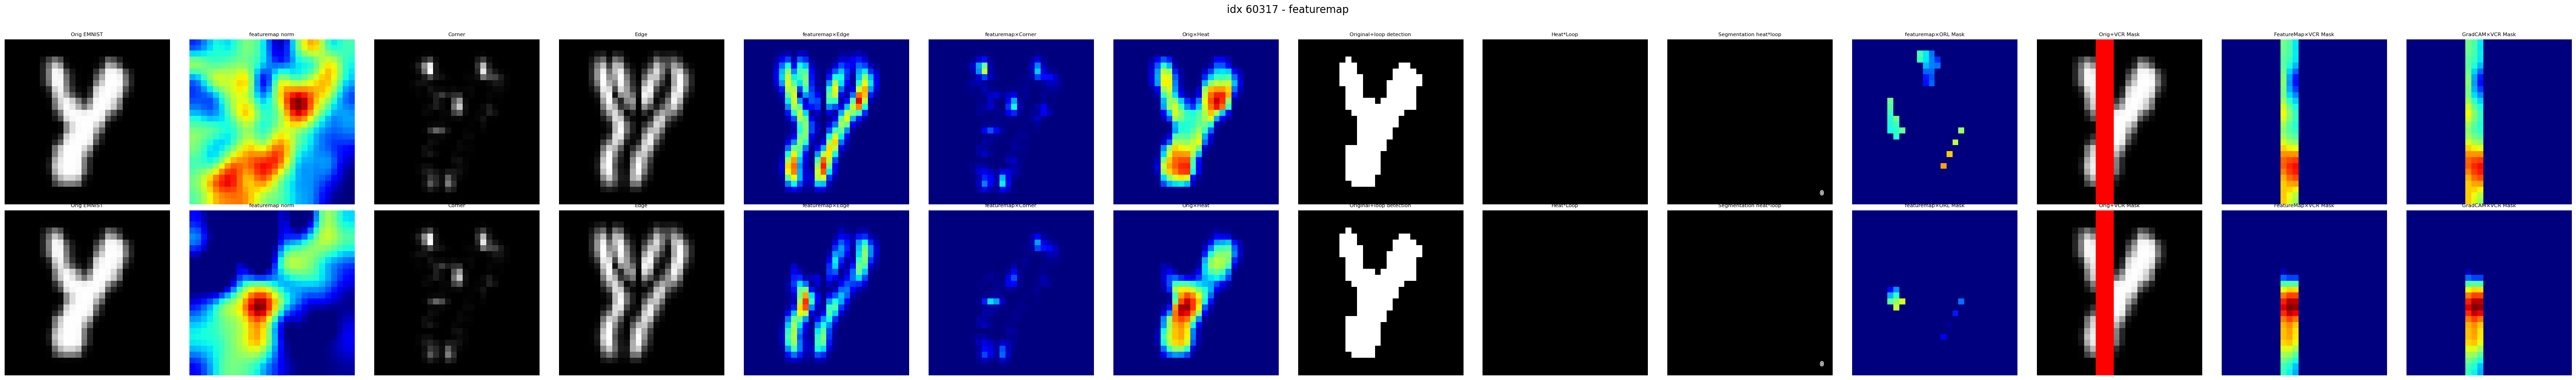

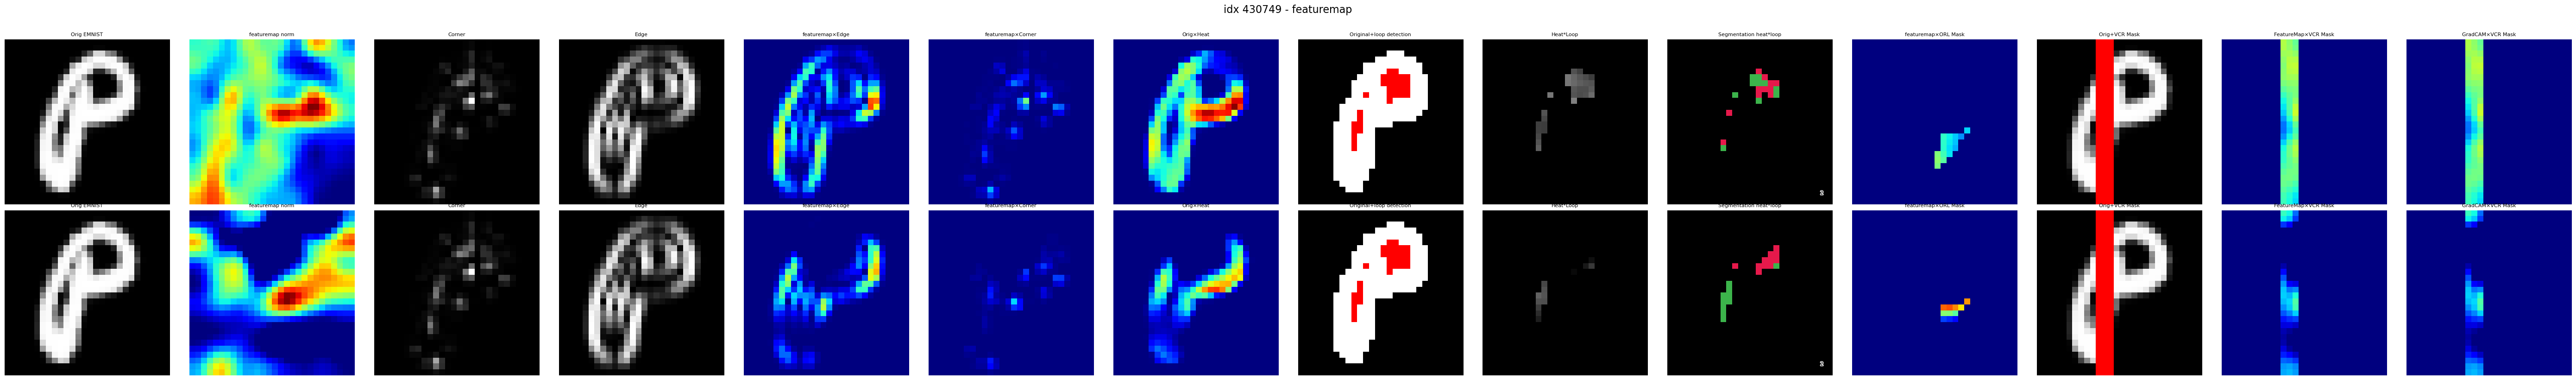

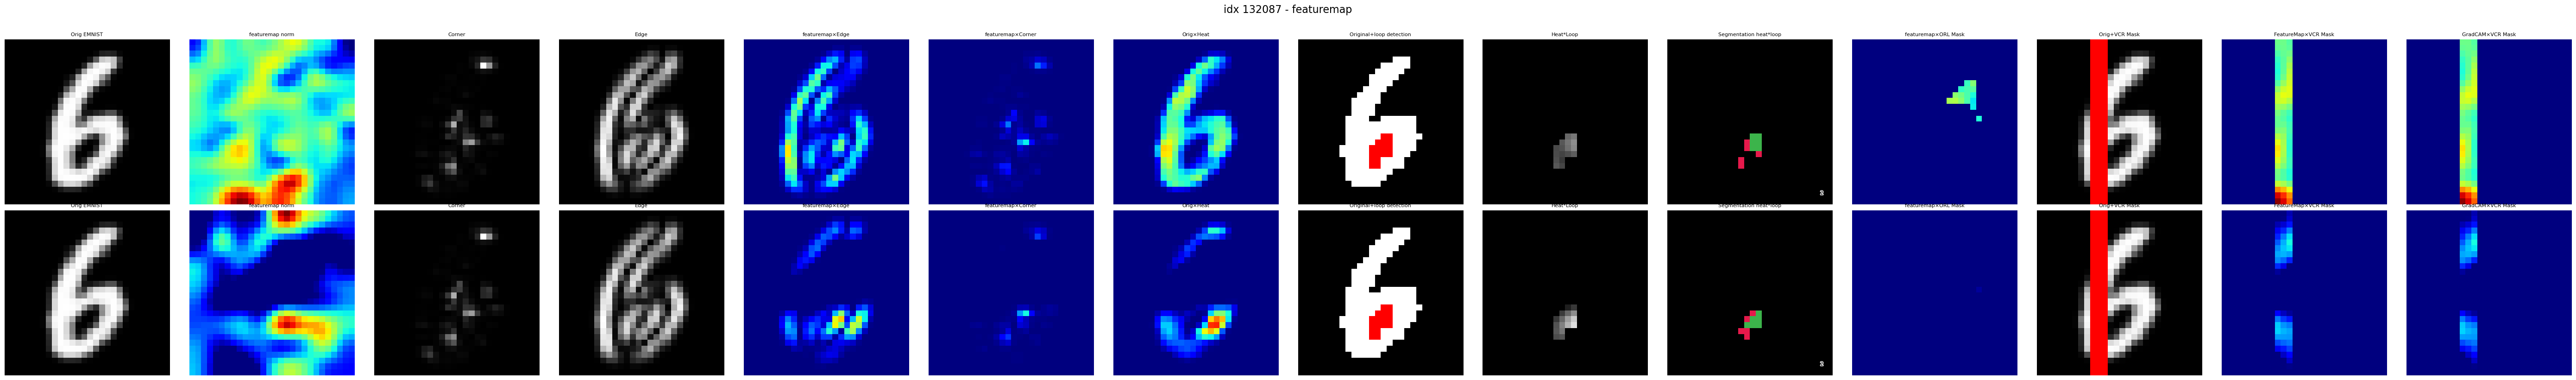

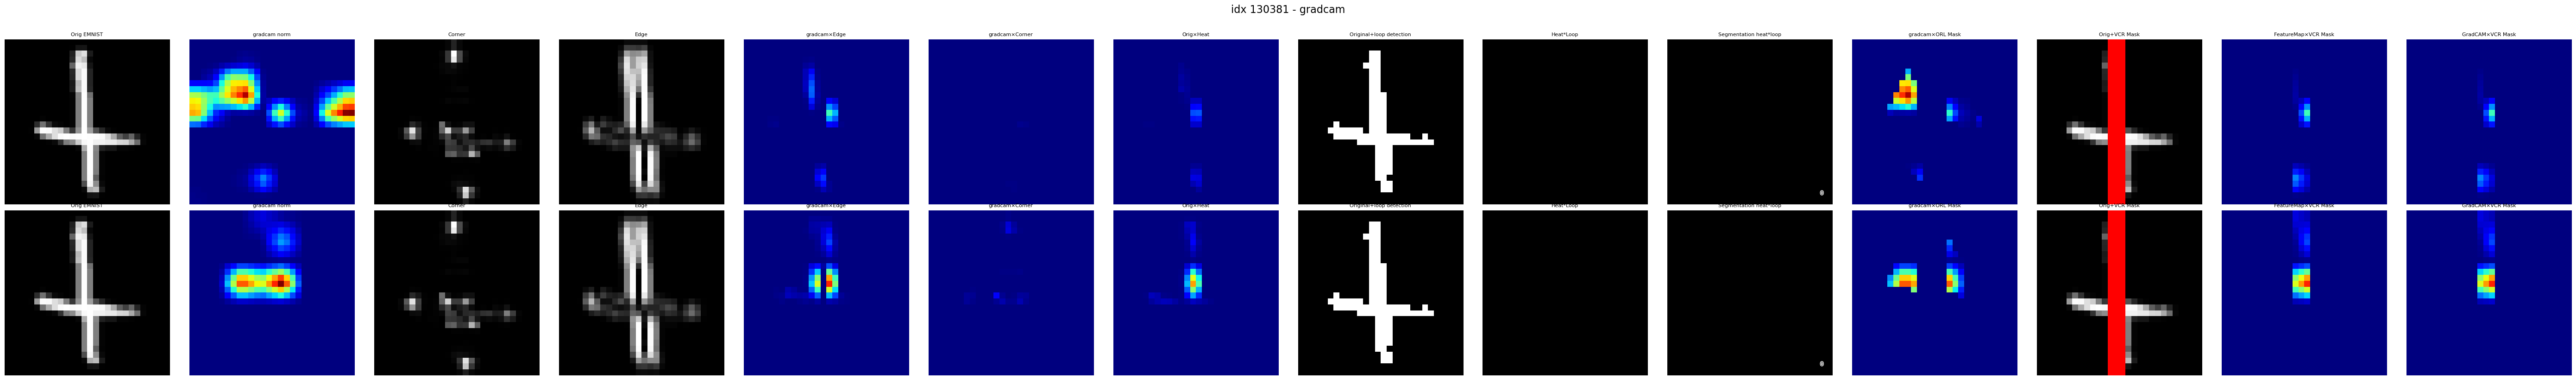

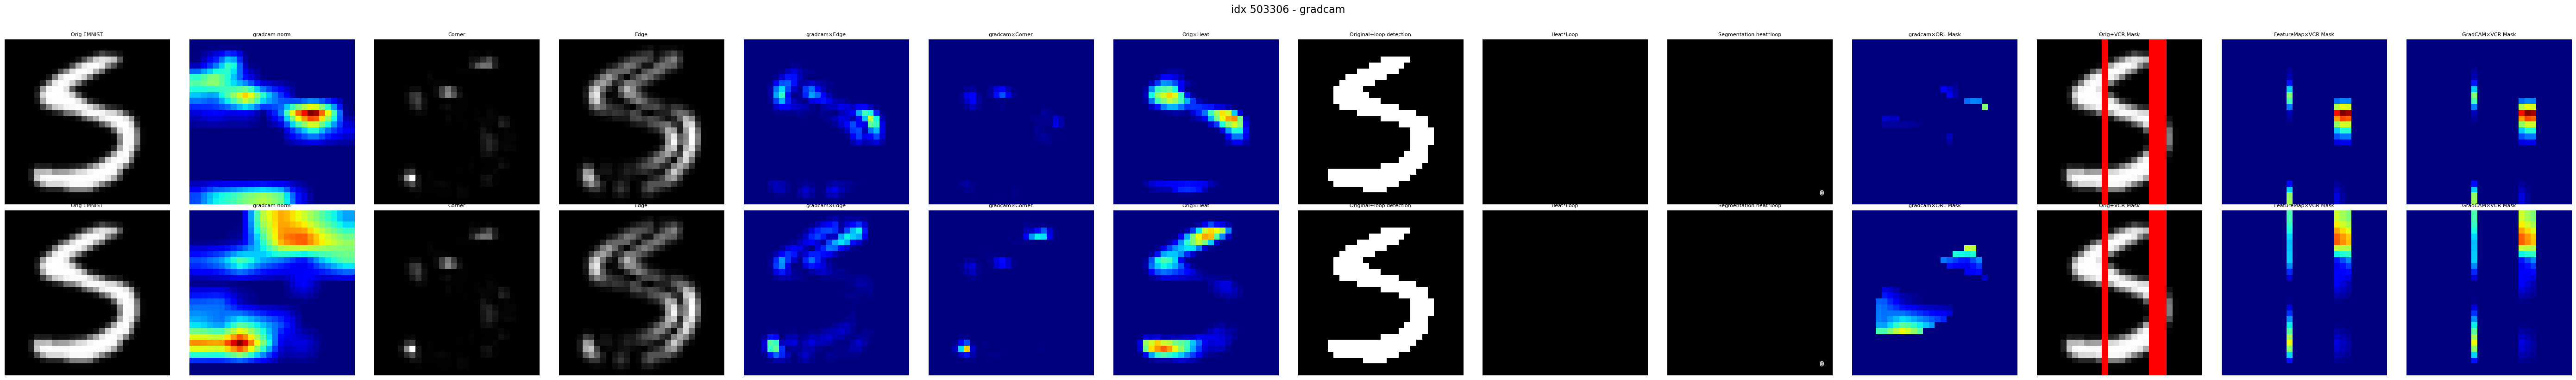

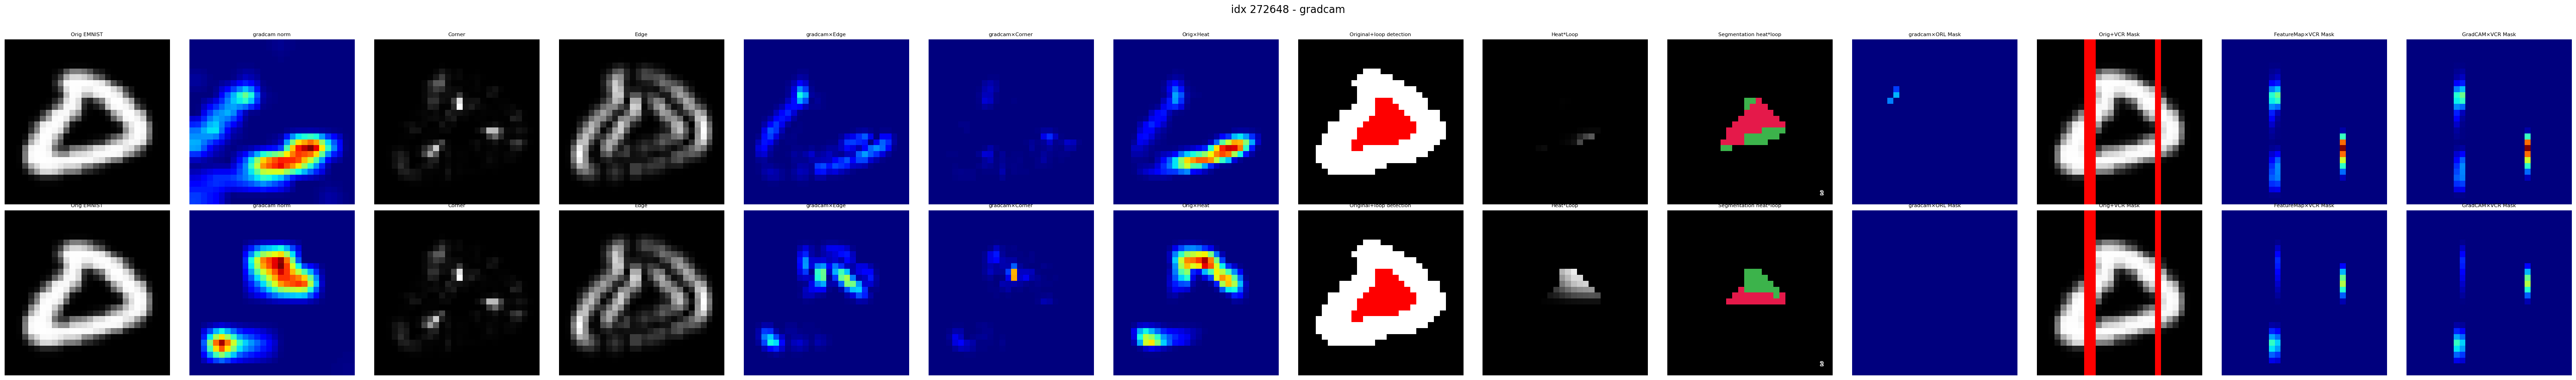

In [139]:
import os
import re
import random
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib import patheffects
import struct
from skimage.morphology import closing, square

# --- ROOT fisso per heatmap files ---
ROOT = Path("/home/magliolo/KAN/ConvolutionalKans/Convolutional-KANs/results")
VARIANTS = ["None"]
MODEL_DIRS = {"Standard_LeNet5": (0, 0), "KaNet5": (5, 3)}
TYPES = {"featuremap": "FeatureMap", "gradcam": "GradCAM"}
SUFFIX = {"featuremap": "_fmap_up.npy", "gradcam": "_gcam_up.npy"}
TOTAL_EPOCHS = 50
# Colormap per heatmap: jet-like scale
HEATMAP_CMAP = plt.get_cmap('jet')

# Percorso dati idx EMNIST
DATA_DIR = '/home/magliolo/.cache/emnist/gzip/'
TRAIN_PATH = os.path.join(DATA_DIR, 'emnist-byclass-train-images-idx3-ubyte')
TEST_PATH  = os.path.join(DATA_DIR, 'emnist-byclass-test-images-idx3-ubyte')

# --- Funzioni di utilità per EMNIST ---
def read_idx_header(fp: str):
    with open(fp, 'rb') as f:
        _, num, rows, cols = struct.unpack('>IIII', f.read(16))
    return num, rows, cols

train_n, IMG_ROWS, IMG_COLS = read_idx_header(TRAIN_PATH)
test_n, _, _               = read_idx_header(TEST_PATH)

def read_idx_image(fp: str, idx: int) -> np.ndarray:
    with open(fp, 'rb') as f:
        f.seek(16 + idx * IMG_ROWS * IMG_COLS)
        buf = f.read(IMG_ROWS * IMG_COLS)
    return np.frombuffer(buf, dtype=np.uint8).reshape(IMG_ROWS, IMG_COLS)

def get_emnist_image(idx: int) -> np.ndarray:
    if idx < train_n:
        return read_idx_image(TRAIN_PATH, idx)
    else:
        return read_idx_image(TEST_PATH, idx - train_n)

# --- Loop mask extraction via Contour-Hierarchy Clean ---
def mask_hierarchy(bin_img: np.ndarray) -> np.ndarray:
    contours, hierarchy = cv2.findContours(bin_img, cv2.RETR_CCOMP, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(bin_img, dtype=np.uint8)
    if hierarchy is None:
        return mask.astype(bool)
    for i, h in enumerate(hierarchy[0]):
        if h[3] != -1:
            cv2.drawContours(mask, contours, i, 255, thickness=-1)
    return mask.astype(bool)

def mask_hierarchy_clean(bin_img: np.ndarray) -> np.ndarray:
    hole = mask_hierarchy(bin_img)
    hole = hole & (bin_img == 0)
    hole[0, :] = False
    hole[-1, :] = False
    hole[:, 0] = False
    hole[:, -1] = False
    return hole

# --- Convexity Defects Opening Mask for ORL Overlay ---
def convexity_defects_opening_mask(img_gray: np.ndarray,
                                   dilate_iter: int = 1,
                                   dilate_kernel_size: int = 3) -> np.ndarray:
    _, binary = cv2.threshold(img_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    binary = (binary // 255).astype(np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,
                                       (dilate_kernel_size, dilate_kernel_size))
    dilated = cv2.dilate(binary, kernel, iterations=dilate_iter)
    contours, _ = cv2.findContours(dilated*255,
                                   cv2.RETR_EXTERNAL,
                                   cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.zeros_like(binary, dtype=np.uint8)
    cnt = contours[0]
    hull = cv2.convexHull(cnt, returnPoints=False)
    if hull is None or len(hull) <= 3:
        return np.zeros_like(binary, dtype=np.uint8)
    defects = cv2.convexityDefects(cnt, hull)
    if defects is None:
        return np.zeros_like(binary, dtype=np.uint8)
    mask = np.zeros_like(binary, dtype=np.uint8)
    for i in range(defects.shape[0]):
        s, e, f, _ = defects[i, 0]
        tri = np.array([cnt[s][0], cnt[f][0], cnt[e][0]])
        cv2.fillConvexPoly(mask, tri, 1)
    edges = cv2.Canny(img_gray, 30, 100)
    kernel_edge = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    edges_dilated = cv2.dilate(edges, kernel_edge, iterations=1)
    mask[edges_dilated > 0] = 0
    return mask

# --- Quantile clustering (K=3) ---
def cluster_quantile(grad: np.ndarray, mask: np.ndarray, K: int = 3) -> np.ndarray:
    lbl = np.zeros_like(grad, dtype=int)
    vals = grad[mask]
    if vals.size == 0:
        return lbl
    thresholds = [np.percentile(vals, 100 * i / K) for i in range(1, K)]
    seg = np.digitize(vals, bins=thresholds)
    lbl[mask] = seg
    return lbl

# --- Collect heatmap files ---
def collect_heatmap_files() -> dict[str, list[Path]]:
    files_by_type = {ht: [] for ht in SUFFIX}
    for variant in VARIANTS:
        for model, (g, s) in MODEL_DIRS.items():
            for htype, suf in SUFFIX.items():
                base = ROOT / f"results_{variant}_SGD_lr0.01_{g}_{s}" / model / TYPES[htype]
                for epoch in range(1, TOTAL_EPOCHS+1):
                    folder = base / f"epoch_{epoch}" / "extracted_random_examples" / "Upsampled"
                    if folder.exists():
                        files_by_type[htype] += list(folder.glob(f"*{suf}"))
    return files_by_type

# --- Main comparison and display ---
def show_comparison_and_table(sample_size: int = 3):
    files_by_type = collect_heatmap_files()
    for htype, files in files_by_type.items():
        fm = {m: [fp for fp in files if f"/{m}/" in fp.as_posix()] for m in MODEL_DIRS}
        idxs = {m: {int(re.search(r'idx_(\d+)', fp.stem).group(1)) for fp in fps} for m, fps in fm.items()}
        common = set.intersection(*idxs.values())
        sample_idxs = random.sample(list(common), min(sample_size, len(common)))

        for idx in sample_idxs:
            # compute VCR mask on original
            raw = get_emnist_image(idx)
            orig = np.rot90(np.fliplr(raw), k=1)
            orig_n = orig.astype(np.float32) / 255.0
            h_o, w_o = orig_n.shape
            tau_vcr = 0.1
            lvccr_j = np.zeros(w_o)
            for j in range(w_o):
                col_bin = (orig_n[:, j] >= tau_vcr).astype(int)
                runs = np.diff(np.where(np.concatenate(([col_bin[0]], col_bin[:-1] != col_bin[1:], [True])))[0])[::2]
                L = runs.max() if runs.size > 0 else 0
                lvccr_j[j] = L / h_o
            thr_v = np.percentile(lvccr_j, 90)
            vcr_mask = (lvccr_j >= thr_v)
            # prepare orig overlay
            orig_rgb = np.stack([orig_n]*3, axis=-1)
            overlay_vcr = orig_rgb.copy()
            overlay_vcr[:, vcr_mask, :] = [1,0,0]

            fig, axes = plt.subplots(2, 14, figsize=(56, 8))
            plt.suptitle(f"idx {idx} - {htype}", y=1.02, fontsize=16)

            for r, model in enumerate(MODEL_DIRS):
                # reload orig, masks
                _, bin_char = cv2.threshold((orig_n*255).astype(np.uint8), 0, 255,
                                            cv2.THRESH_BINARY | cv2.THRESH_OTSU)
                loop_mask = mask_hierarchy_clean(bin_char)
                mask_orl = convexity_defects_opening_mask((orig_n*255).astype(np.uint8))
                # heatmap
                fp = next(fp for fp in fm[model] if f"idx_{idx}" in fp.stem)
                heat = np.rot90(np.fliplr(np.load(fp).astype(np.float32)), k=1)
                heat_n = heat / (heat.max() or 1.0)
                # edge & corner
                edge = cv2.Sobel(orig_n, cv2.CV_32F, 1, 0, ksize=3)
                edge_n = np.abs(edge) / (np.abs(edge).max() or 1.0)
                corner = cv2.cornerMinEigenVal(orig_n, blockSize=2, ksize=3)
                corner_n = corner / (corner.max() or 1.0)
                # overlays
                letter_mask = bin_char == 255
                overlay_loop = np.stack([letter_mask]*3, axis=-1).astype(float)
                overlay_loop[loop_mask] = [1,0,0]
                # clustering
                lbl3 = cluster_quantile(heat_n * loop_mask.astype(float), loop_mask, K=3)
                colors = [(230/255,25/255,75/255),(60/255,180/255,75/255),(255/255,225/255,25/255)]
                cluster_img = np.zeros_like(np.stack([heat_n*loop_mask]*3, axis=-1))
                for val in np.unique(lbl3):
                    if val > 0: cluster_img[lbl3 == val] = colors[val-1]
                num_cls = len(np.unique(lbl3)) - (1 if 0 in np.unique(lbl3) else 0)

                # basic columns 0-7
                imgs = [orig_n, heat_n, corner_n, edge_n,
                        heat_n*edge_n, heat_n*corner_n, orig_n*heat_n,
                        overlay_loop]
                titles = ['Orig EMNIST', f'{htype} norm', 'Corner', 'Edge',
                          f'{htype}×Edge', f'{htype}×Corner', 'Orig×Heat',
                          'Original+loop detection']
                cmaps = ['gray', HEATMAP_CMAP, 'gray', 'gray',
                         HEATMAP_CMAP, HEATMAP_CMAP, HEATMAP_CMAP,
                         None]
                for c in range(len(imgs)):
                    ax = axes[r, c]
                    if cmaps[c]:
                        ax.imshow(imgs[c], cmap=cmaps[c], vmin=0, vmax=1)
                    else:
                        ax.imshow(imgs[c])
                    if c == 0:
                        ax.set_ylabel(model, fontsize=14)
                    ax.set_title(titles[c], fontsize=8)
                    ax.axis('off')

                # 8: Heat*Loop
                ax = axes[r, 8]
                ax.imshow(heat_n * loop_mask.astype(float), cmap='gray', vmin=0, vmax=1)
                ax.set_title('Heat*Loop', fontsize=8)
                ax.axis('off')

                # 9: Segmentation heat*loop
                ax = axes[r, 9]
                ax.imshow(cluster_img)
                ax.set_title('Segmentation heat*loop', fontsize=8)
                ax.text(26, 26, str(num_cls), fontsize=8, color='black', ha='right', va='bottom', path_effects=[patheffects.withStroke(linewidth=2, foreground='white')])
                ax.axis('off')

                # 10: FeatureMap×ORL Mask
                masked_orl = heat_n * mask_orl.astype(float)
                ax = axes[r, 10]
                ax.imshow(masked_orl, cmap=HEATMAP_CMAP, vmin=0, vmax=1)
                ax.set_title(f'{htype}×ORL Mask', fontsize=8)
                ax.axis('off')

                # 11: Orig+VCR Mask
                ax = axes[r, 11]
                ax.imshow(overlay_vcr)
                ax.set_title('Orig+VCR Mask', fontsize=8)
                ax.axis('off')

                # 12: FeatureMap×VCR Mask
                feat_vcr = heat_n * vcr_mask.astype(float)
                ax = axes[r, 12]
                ax.imshow(feat_vcr, cmap=HEATMAP_CMAP, vmin=0, vmax=1)
                ax.set_title('FeatureMap×VCR Mask', fontsize=8)
                ax.axis('off')

                # 13: GradCAM×VCR Mask
                grad_vcr = heat_n * vcr_mask.astype(float)
                ax = axes[r, 13]
                ax.imshow(grad_vcr, cmap=HEATMAP_CMAP, vmin=0, vmax=1)
                ax.set_title('GradCAM×VCR Mask', fontsize=8)
                ax.axis('off')

            plt.tight_layout()
            plt.show()

if __name__ == "__main__":
    random.seed(42)
    show_comparison_and_table(sample_size=3)
